# Phase 1 – FastF1 Data Exploration

Goal:
Explore Formula 1 race session data using FastF1 and understand the structure
before building reusable analytics modules.

In [5]:
import os
import sys
project_root=os.path.abspath("..")
sys.path.insert(0,project_root)


In [6]:

import fastf1
import pandas as pd
import matplotlib.pyplot as plt




CACHE before loading any data will improve performance and avoid rate limits


#step 2: load the race session

In [7]:
from src.data.fastf1_loader import load_session

session = load_session(
    2024,
    "British Grand Prix",
    "R",
)

core           INFO 	Loading data for British Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info


req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
core        WARNING 	Failed to perform lap accuracy check - all laps marked as inaccurate (driver 10)
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['44', '1', '4', '81', '55', '27', '18', '14', '23', '22', '2', '20', '3', '16', '77', '31', '11', '24', '63', '10']


In [8]:
print("="*50)
print("Event Name:",session.event["EventName"])
print("Event Date:",session.event["EventDate"])
print("Session:",session.name)
print("="*50)

Event Name: British Grand Prix
Event Date: 2024-07-07 00:00:00
Session: Race


###OBSERVATION
successfully loaded the 2024 British Grand Prix Session using Fastf1 loader


In [9]:
results=session.results
print(results.head())

   DriverNumber BroadcastName Abbreviation        DriverId         TeamName  \
44           44    L HAMILTON          HAM        hamilton         Mercedes   
1             1  M VERSTAPPEN          VER  max_verstappen  Red Bull Racing   
4             4      L NORRIS          NOR          norris          McLaren   
81           81     O PIASTRI          PIA         piastri          McLaren   
55           55       C SAINZ          SAI           sainz          Ferrari   

   TeamColor    TeamId FirstName    LastName        FullName  ... Position  \
44    27F4D2  mercedes     Lewis    Hamilton  Lewis Hamilton  ...      1.0   
1     3671C6  red_bull       Max  Verstappen  Max Verstappen  ...      2.0   
4     FF8000   mclaren     Lando      Norris    Lando Norris  ...      3.0   
81    FF8000   mclaren     Oscar     Piastri   Oscar Piastri  ...      4.0   
55    E80020   ferrari    Carlos       Sainz    Carlos Sainz  ...      5.0   

   ClassifiedPosition  GridPosition  Q1  Q2  Q3         

In [10]:
print(results.columns)

Index(['DriverNumber', 'BroadcastName', 'Abbreviation', 'DriverId', 'TeamName',
       'TeamColor', 'TeamId', 'FirstName', 'LastName', 'FullName',
       'HeadshotUrl', 'CountryCode', 'Position', 'ClassifiedPosition',
       'GridPosition', 'Q1', 'Q2', 'Q3', 'Time', 'Status', 'Points', 'Laps'],
      dtype='object')


In [11]:
results_table=results[
    [
    "Abbreviation",
    "TeamName",
    "GridPosition",
    "Position",
    "Points",
    "Status"
    ]
]
results_table

,Abbreviation,TeamName,GridPosition,Position,Points,Status
44,HAM,Mercedes,2.0,1.0,25.0,Finished
1,VER,Red Bull Racing,4.0,2.0,18.0,Finished
4,NOR,McLaren,3.0,3.0,15.0,Finished
81,PIA,McLaren,5.0,4.0,12.0,Finished
55,SAI,Ferrari,7.0,5.0,11.0,Finished
27,HUL,Haas F1 Team,6.0,6.0,8.0,Finished
18,STR,Aston Martin,8.0,7.0,6.0,Finished
14,ALO,Aston Martin,10.0,8.0,4.0,Finished
23,ALB,Williams,9.0,9.0,2.0,Finished
22,TSU,RB,13.0,10.0,1.0,Finished


In [12]:
results_table["PositionChange"] = (results_table["GridPosition"] - results_table["Position"])

C:\Users\mehra\AppData\Local\Temp\ipykernel_17024\1749399970.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  results_table["PositionChange"] = (results_table["GridPosition"] - results_table["Position"])


In [13]:
results_table=results_table.sort_values(by="PositionChange", ascending=False)

In [14]:
results_table

,Abbreviation,TeamName,GridPosition,Position,Points,Status,PositionChange
20,MAG,Haas F1 Team,17.0,12.0,0.0,Finished,5.0
22,TSU,RB,13.0,10.0,1.0,Finished,3.0
11,PER,Red Bull Racing,20.0,17.0,0.0,Lapped,3.0
1,VER,Red Bull Racing,4.0,2.0,18.0,Finished,2.0
3,RIC,RB,15.0,13.0,0.0,Lapped,2.0
31,OCO,Alpine,18.0,16.0,0.0,Lapped,2.0
14,ALO,Aston Martin,10.0,8.0,4.0,Finished,2.0
55,SAI,Ferrari,7.0,5.0,11.0,Finished,2.0
18,STR,Aston Martin,8.0,7.0,6.0,Finished,1.0
81,PIA,McLaren,5.0,4.0,12.0,Finished,1.0


In [18]:
drivers = results_table["Abbreviation"]

position_change = results_table["PositionChange"]

colors = [
    "green" if x > 0 else
    "red" if x < 0 else
    "gray"
    for x in position_change
]

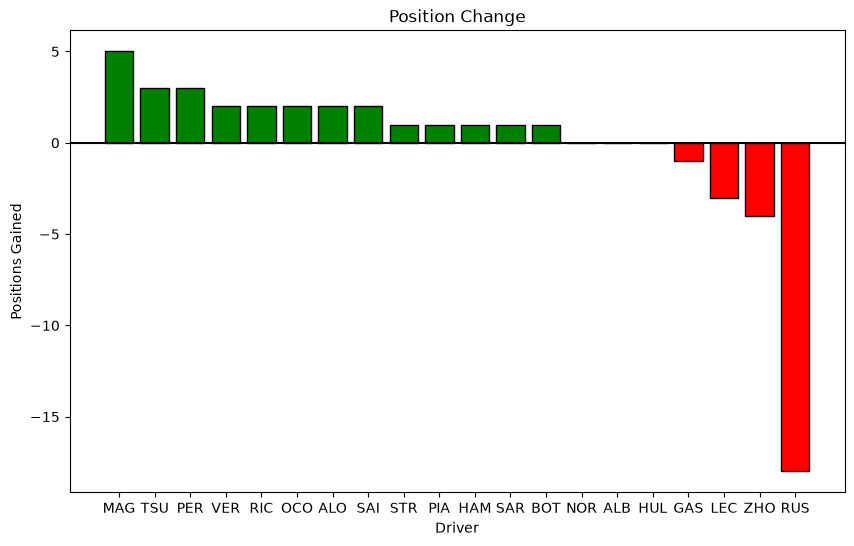

In [19]:
fig, ax = plt.subplots(figsize=(10,6))

ax.bar(drivers, position_change,
       color=colors,
       edgecolor="black")

ax.axhline(0,color="black")
ax.set_title("Position Change")
ax.set_xlabel("Driver")
ax.set_ylabel("Positions Gained")

fig.savefig(
    "../docs/phase_01/screenshots/position_change.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()